# **Catalogue Simulations for the WISEMAN simulator**

- **WISEMAN** \[1\] is a physics-based Monte Carlo C++ simulator built to assess the performace of the **Wide Field Monitor** (WFM) instrument, originally designed and developed for the LOFT, STROBE-X, eXTP and LEM-X \[2, 3\] space missions.

- This software provides a realistic photon-by-photon Monte Carlo simulation from the astrophysical sources down to the scientific data at the instrument level for a single WFM coded-mask camera. Each photon is generated at a given instant from a given sky direction and with a given energy, transported through a coded-mask camera, detected, and processed by the on-board front-end and back-end electronics.

- This notebook exploits the `wmsims` mini-package to simulate a given number of sources in a sky-field, with the possibility to specify custom PDFs for the sources coordinates and flux values distributions. The initialised sources are then stored into a database and saved as a `CSV` file.

**Libraries**

In [1]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray
from pandas import DataFrame

from bloodmoon.mask import CodedMaskCamera
import darksun as ds
from darksun.data import Log

import wmsims as wm
from wmsims.fields import CameraPointer, Coords, Source

In [2]:
# plotting setup
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.ioff()

**Coded-mask cameras mask design and pointings setup**

In [3]:
base_path: str = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations"
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

wfm: CodedMaskCamera = wm.init_cameras_mask(f"{base_path}/{MASK_FITS}")
sdl: CameraPointer = wm.define_unit_pointings(
    z_axis_RA=266.4,
    z_axis_DEC=-28.94,
    x_axis_RA=266.4,
    x_axis_DEC=61.06,
)

**Catalogue setup**

In [4]:
n_sources: int = 40
fov: tuple[float, float] = (-40.0, 40.0)   # [deg]
f_min: float = 4.0e-2                      # [Crab]
f_max: float = 10.0                        # [Crab]

**Simulate sources**

In [ ]:
# -- simul sources camera local-frame angular sources
coords: tuple[Coords, ...] = wm.simul_coords(
    n_sources=n_sources,
    fov_along_x=fov,
    fov_along_y=fov,
)

# -- simul sources fluxes
## custom PDF kernel for sources flux distribution
#from scipy.special import gamma
#
#def mod_kernel(
#    x: NDArray,
#    alpha: float,
#    k: float,
#    beta: float,
#) -> NDArray:
#    """Custom exp - power law probability distribution function."""
#    f = (alpha + 1) / beta
#    a = beta * np.pow(k, f) / gamma(f)
#    t = - k * np.pow(x, beta)
#    return np.abs(a * np.pow(x, alpha) * np.exp(t))
#
#factors = (2.0, 4.0, 2.0)
#flux_pdf: Callable[[NDArray], NDArray] = wm.config_pdf(mod_kernel, *factors)
#
#fluxes: tuple[float, ...] = wm.simul_fluxes(
#    n_sources=n_sources,
#    f_min=f_min,
#    f_max=f_max,
#    pdf=flux_pdf,
#)

# handmade sources flux distribution
fluxes: tuple[float, ...] = wm.handmade_fluxes(
    n_sources=(2, 3, 5, 10, 8, 6, 3, 2, 1),
    flux_lims=(
        (3.5e-2, 7.0e-2), (7.0e-2, 1.0e-1), (1.0e-1, 4.0e-1),
        (4.0e-1, 8.0e-1), (8.0e-1, 9.0e-1), (9.0e-1, 1.0),
        (1.0, 2.0), (2.0, 3.0), (3.0, 15.0),
    ),
)

# -- get sources
sources: tuple[Source, ...] = wm.get_sources(coords, fluxes)

print(
    f"Total # of sources: {len(fluxes)}\n"
    f"Total flux from sources: {sum(fluxes):.3f} Crab\n"
)

Total # of sources: 40
Total flux from sources: 33.389 Crab



**Catalogue generation and visualisation**

In [ ]:
SAVE_SKYFIELD: bool = True
SAVE_CATALOGUE: bool = False

SAVE_TO: str = '/home/edoardo/Desktop'
#SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'

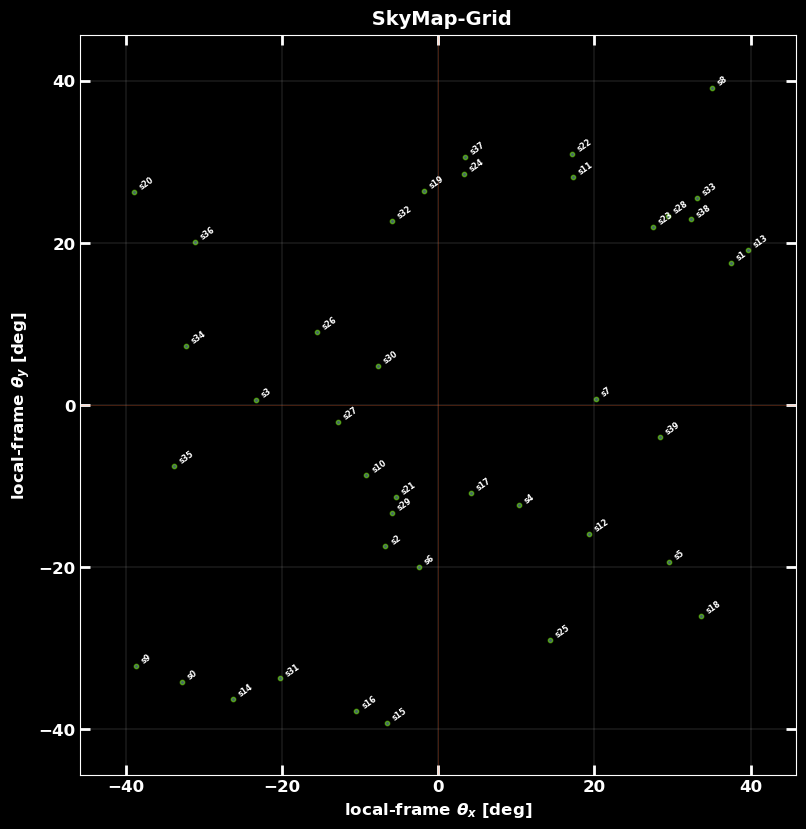

In [25]:
# gen Log structure for sources and show sky-field
log: Log = wm.gen_data_log(sources)

ds.skyfield_map(
    log=log,
    camera=wfm,
    show_IDs=True,
    save_to=(
        ds.savefig_to(SAVE_TO, 'skymap', overwrite=True)
        if SAVE_SKYFIELD else None
    ),
)

# TODO:
#   - print source significance value on skymap grid

In [ ]:
from bloodmoon.coords import angle2shift
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import _mask_pattern_projection


def source_significance(
    camera: CodedMaskCamera,
    flux: float,
    exposure: float,
    angle_x: float,
    angle_y: float,
    vignetting: bool = True,
) -> float:
    """
    Computes a source significance taking into account its position
    and the sky background counts per unit area on the detector.

    The output value is a upper limit estimation, since the source
    is assumed to be isolated in the sky-field. This means that the
    SNR estimate does not include the coding noise from other sources.

    Flux is in [Crab], exposure in [s], angles in [deg].
    """
    def pattern_projection(
        shift_x: float,
        shift_y: float,
    ) -> NDArray:
        """Projects the mask pattern on the detector."""
        # mask pattern projection WTO detector sp. res.
        sg = _mask_pattern_projection(
            camera, shift_x, shift_y, vignetting, False,
        )
        # extract detector
        i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
        detector = sg[i_min:i_max, j_min:j_max]
        detector *= camera.bulk
        return detector
    
    def get_effective_area(detector: NDArray) -> float:
        """Computes source effective area from detector in [cm^2]."""
        # pixel area in [cm^2]
        pixel_area = (
            1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
        )
        # factor to consider SDD QE, MLI and filter absorption @ 8keV.
        # https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Effective_area_and_Sens_2D.ipynb
        #           dead layer * QE    * 25 um Be * 300nm Al * 12.5um Kapton
        qe_factor = 0.974      * 0.999 * 0.99527  * 0.99614  *  0.98945
        return detector.sum() * pixel_area * qe_factor

    # setup (bkg_fluence and crab cts/area refers to LEM-X single coded-mask camera)
    bkg_fluence: float = 6.3799 * exposure          # bkg counts per detector unit area [ph/cm2/s]
    crab: float = 2.5737                            # [ph/cm2/Crab/s]
    source_fluence: float = flux * crab * exposure  # [ph/cm2]
    # open_fraction and coding power are [adim]
    open_fraction: float = camera.mask.sum() / camera.mask.size
    coding_power: float = 0.85
    
    # retrieve source effective area and effective open fraction on detector
    shift_x, shift_y = map(
        lambda x: angle2shift(camera, x),
        (angle_x, angle_y),
    )
    detector: NDArray = pattern_projection(shift_x, shift_y)
    off_axis_area: float = get_effective_area(detector)
    effective_open_fraction: float = detector.sum() / detector.size

    # bkg counts correction for sensitivity overestimation
    # https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Effective_area_and_Sens_2D.ipynb
    on_axis: NDArray = pattern_projection(0.0, 0.0)
    on_axis_area: float = get_effective_area(on_axis)
    bkg_fluence_corr: float = (
        bkg_fluence + (1 - off_axis_area / on_axis_area) * source_fluence
    )

    # compute significance
    a: float = coding_power * source_fluence / open_fraction
    b1: float = off_axis_area * (1.0 - effective_open_fraction)
    b2: float = effective_open_fraction * (source_fluence + bkg_fluence_corr) / open_fraction
    return a * np.sqrt(b1 / b2)


theta_x, theta_y = 0.0, 0.0   # [deg]

flux: float = 1.0             # [Crab]
exposure: float = 1.0         # [s]

snr: float = source_significance(
    camera=wfm,
    flux=flux,
    exposure=exposure,
    angle_x=theta_x,
    angle_y=theta_y,
)

sigmas: float = 5.0

crab: float = 1e3  # [mCrab]

print(
    f'Significance for {flux}Crab in {exposure}s at ({theta_x}, {theta_y})deg: {snr:.3f}\n'
    f'...: {sigmas / snr:.5f}\n'
    f'Camera Sensitivity at {sigmas} sigma: {crab / (sigmas / snr):.0f} mCrab\n'
)

def verbose(
    flux: float,
    exposure: float,
    coords: tuple[float, float],
    significance: float,
    sigmas: float,
) -> None:
    """Prints out info on source SNR and camera sensitivity."""
    return None

Significance for 1.0Crab in 1.0s at (0.0, 0.0)deg: 14.030
...: 0.35637
Camera Sensitivity at 5.0 sigma: 2806 mCrab



In [73]:
np.sqrt(50e3)

5 / 14

1000 / (5 / 14)

2800.0

In [ ]:
# - Gen catalogue dataframe
df: DataFrame = wm.make_catalog(
    sources=sources,
    sdl=sdl,
    camera=wfm,
    save_to=(
        f'{SAVE_TO}/catalogue.csv' if SAVE_CATALOGUE else None
    ),
)

<br>
<br>

### **References**

**\[1\]** Ceraudo, F. et al. Development of the end-to-end simulator of the WFM camera, Vol. 13093 of Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series, 130936T (2024)

**\[2\]** Del Monte, E. et al., Status of the Lunar Electromagnetic Monitor in X-rays (LEM-X), in [Space Telescopes and Instrumentation 2024: Ultraviolet to Gamma Ray], den Herder, J.-W. A., Nikzad, S., and Nakazawa, K., eds., Society of Photo-Optical Instrumentation Engineers (SPIE) Conference Series 13093, this proceedings (2024)

**\[3\]** Del Monte, E. et al., The Lunar Electromagnetic Monitor in X-rays (LEM-X), _in preparation_, (2025)